<a href="https://colab.research.google.com/github/tharold4096/Tobias_INFO4670_Fall2026/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** Tobias Harold    **Date:** 9/6/2026

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style — keeps this notebook's charts looking like the slides
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# STEP 1 — GET THE DATA. Pick ONE option, then run this cell.
# ============================================================

#DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read the files straight from Google Drive.
# To use this instead, uncomment the three lines below and edit the path
# so it points at the folder that holds your CSVs:
#from google.colab import drive
#drive.mount("/content/drive")
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/INFOPROJ"

# ---------- load (works for either option) ----------
import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
courses = pd.read_csv(os.path.join(DATA_DIR, "course_enrollments.csv"))  # used in a later week

students.head()
#weekly.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

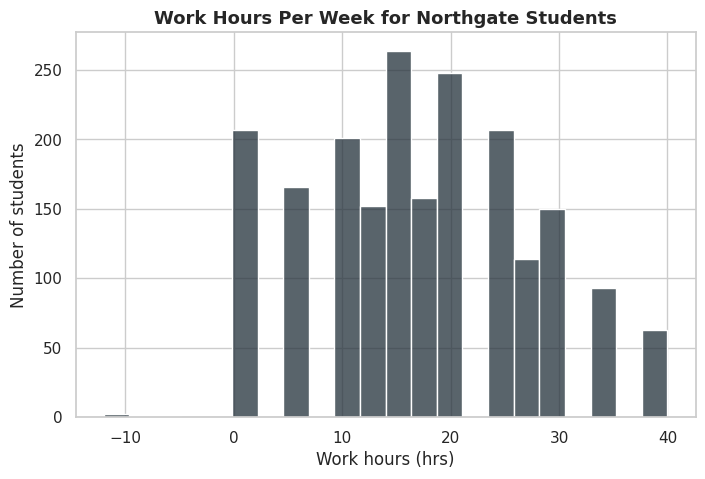

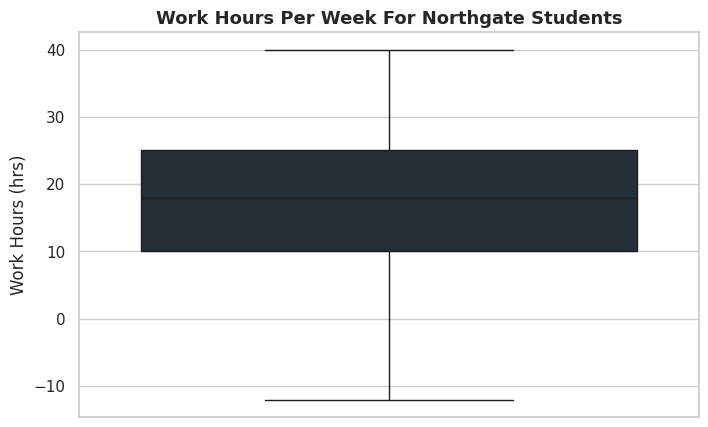

In [4]:

#Histogram
fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Work Hours Per Week for Northgate Students")
ax.set_xlabel("Work hours (hrs)")
ax.set_ylabel("Number of students")
plt.show()

#Boxplot
fig, ax = plt.subplots()
sns.boxplot(data=students, y="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Work Hours Per Week For Northgate Students")
ax.set_ylabel("Work Hours (hrs)")
plt.show()

The objective was to identify the average number of work hours per week for northgate students. After visualizing the data using a histogram and box plot, we can see the median lands just a little over 20 hours per week, with most hovering between 10 and 20 hours. The hours range from 0-40, with 40 being the maximum, with no outliers. The individuals working 40 stand out as the minority, however, clearly showing that full time work is not the most popular choice during college. Most students prefer the 10-20 range. I may change the bins to get a better view of what is going on, rather than leaving it so spaced out.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

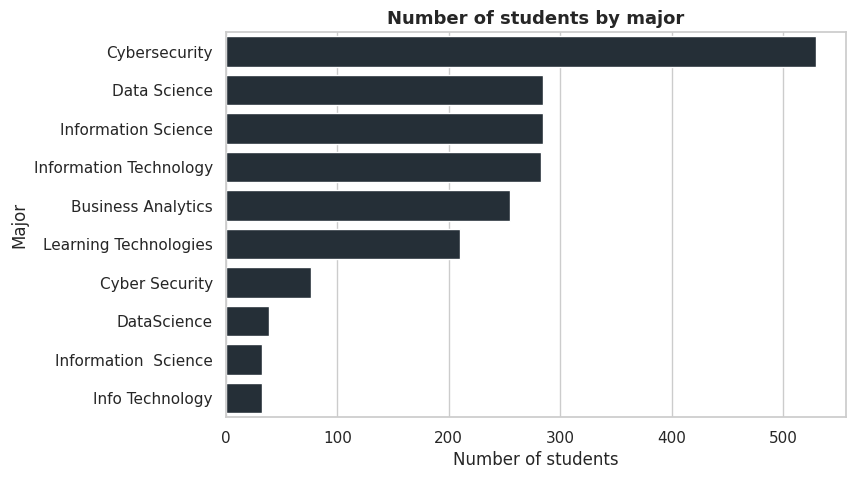

In [5]:
order = students["major"].value_counts().index          # sort by count
fig, ax = plt.subplots()
sns.countplot(data=students, y="major", order=order, color=NAVY, ax=ax)
ax.set_title("Number of students by major")
ax.set_xlabel("Number of students")
ax.set_ylabel("Major")
plt.show()

This chart shows the number of students in each major. The objective was to compare the enrollment between different majors. A majority of students are enrolled in cybersecurity, reaching almost double the second highest major at this university. The lowest seems to be a tie between Information Science and Info Technology, with the rest being fairly even. There is a failure to detect Cyber Security and Cybersecuirty as one major, meaning that the actual catagory is an underestimate of the true number of students enrolled in that major. I would change the catagories and add more advanced data filtering to merge some catagories into one.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

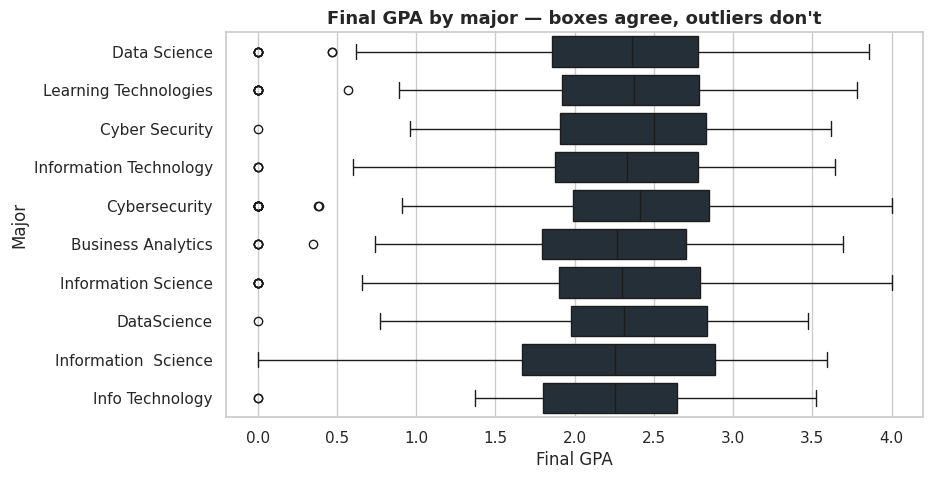

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=students, x="final_gpa", y="major", color=NAVY, ax=ax)
ax.set_title("Final GPA by major — boxes agree, outliers don't")
ax.set_xlabel("Final GPA")
ax.set_ylabel("Major")
plt.show()

This boxplot shows the final GPA across majors. The goal of these boxplots was to compare the final GPA between majors. While all the GPAs are relatively similar in medians, it is the small variances that matter. Overall, Cyber Security had the highest average GPA according to the graph, though no median fell below 2.25. There were obvious outliers, most being 0 or exceptionally low GPAs, with not outliers being high, as 4.0 is within the relevant IQRs. So while there is general variation between majors, no major stands out an exceptional amount above or below others. Again, the correction of the catagories, and potentially changing the identification of outliers would be a further step to take in sanitizing data.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

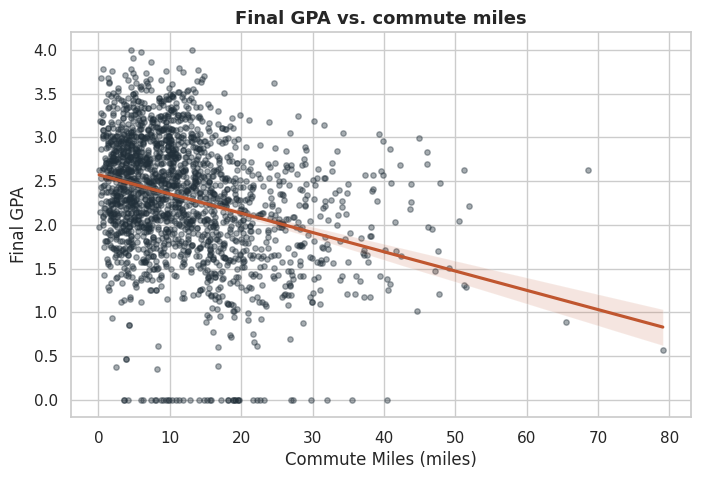

In [7]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa",
            scatter_kws={"s": 15, "color": NAVY, "alpha": 0.4},
            line_kws={"color": RUST}, ax=ax)
ax.set_title("Final GPA vs. commute miles")
ax.set_xlabel("Commute Miles (miles)")
ax.set_ylabel("Final GPA")
plt.show()

The goal was to identify if there was a relationship between commute distance and final GPA, comparing both in a scatterplot. Upon generating a scatterplot with a trendline, it can be concluded that there is a soft negative correlation between the distance and the GPA. The longer the commute miles, the lower the GPA on average. However, there are plenty of outliers, the commute miles less than 20 GPAs range from 1-4 for the bulk, and there are notably high GPAs for the extreme commute distances. However, we cannot safely say that the commute time is what causes this relationship, as correlation is not causation, and there could be several other factors in play, such as internet courses or bias in the commute distance. Cross reference with other patterns could be used to see trengs in the future. One unexpected note is that there are no 0 GPAs past a certain commute distance- implying drop outs or persistent effort potentially.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

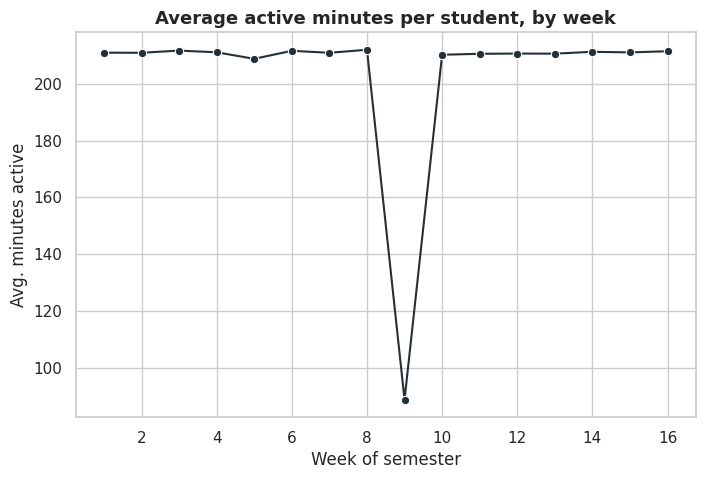

In [8]:
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active",
             color=NAVY, marker="o", ax=ax)
ax.set_title("Average active minutes per student, by week")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Avg. minutes active")
plt.show()

The chart compares all students minutes actives during different weeks of the semester. The objective is to identify fluctutations in activity and to see changes throughout the semester. The chart is very consistent, showing almost now alteration week by week, until the 9th week of the semester. This is a huge outlier and shows a massive drop in student activity, most likely due to a break of a week or so. I may change the scale of the chart, filtering out week 9 in order to zoom in on the rest of the weeks, though the variation is so minimal, any conclusions draw may be simply extrapolation.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** How does a student's age correlate to their living situation?



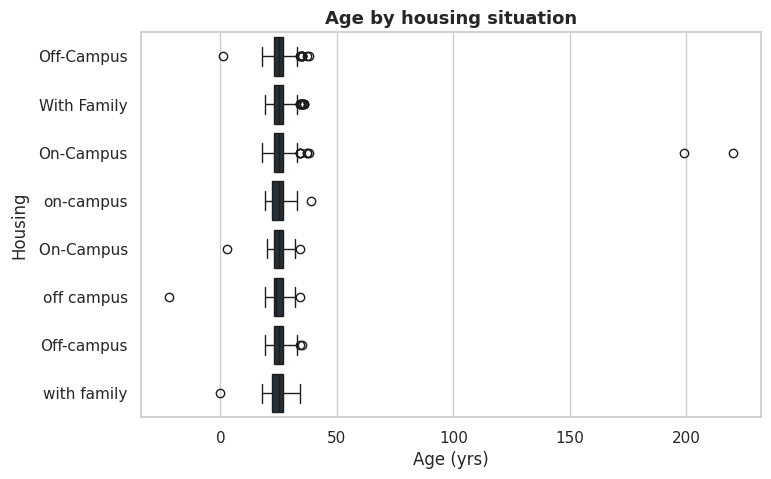

In [9]:
#Using a two variables distributions, one categorical
fig, ax = plt.subplots()
sns.boxplot(data=students, x="age", y="housing", color=NAVY, ax=ax)
ax.set_title("Age by housing situation")
ax.set_xlabel("Age (yrs)")
ax.set_ylabel("Housing")
plt.show()

This chart shows the different bins of housing by an individuals age. The question is how does an individual's age affect their living situation; but that question may remain unanswered. There does not seem to be any noticable correlation between living situation and age, though most of that may be due to two major errors with the data. The first is that the catagories for housing are split into hypenatied and case sensitive bins, which misinterprets the different functionalities. Additionally, there are major age outliers, reaching over 200, which is junk data and should be discarded. Until the data set is cleaned, no meaningful conclusions can be drawn from it, so worth revisiting in the future.